In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import arviz as az

from cmdstanpy import CmdStanModel

In [37]:
model_1ht = CmdStanModel(
    stan_file="models/processing_tree_1high.stan"
)
model_2ht = CmdStanModel(
    stan_file="models/processing_tree_2high.stan"
)

00:14:47 - cmdstanpy - INFO - compiling stan file C:\Users\benwertz\Documents\GitHub\CognitiveModeling_TestRepo\hw4\problem2\models\processing_tree_2high.stan to exe file C:\Users\benwertz\Documents\GitHub\CognitiveModeling_TestRepo\hw4\problem2\models\processing_tree_2high.exe
00:16:41 - cmdstanpy - INFO - compiled model executable: C:\Users\benwertz\Documents\GitHub\CognitiveModeling_TestRepo\hw4\problem2\models\processing_tree_2high.exe


In [38]:
original_words = []
with open("data/original_wordlist.txt") as file:
    original_words = [word.strip() for word in file.read().split(", ")]

test_words = []
with open("data/test_wordlist.txt") as file:
    test_words = [word.strip() for word in file.read().split(", ")]

subject_responses = []
with open("data/subject_responses.txt") as file:
    subject_responses = [(a.split(":")[0].capitalize(), int(a.split(":")[1].upper() != "NO")) for a in file.read().splitlines()]


In [39]:
# Number of old words in the test wordlist
N_old = len(set(original_words) & set(test_words))

# Number of new words in the test wordlist
N_new = len(test_words) - N_old


# Number of correctly identified old words in the subject's response
old_answers = 0
# Number of misidentified new words
new_answers = 0

for word,is_response_old in subject_responses:
    if is_response_old:
        if word in original_words:
            old_answers+=1
        else:
            new_answers+=1

print(f"N_old = {N_old}, N_new = {N_new}")
print(f"old_answers = {old_answers}, new_answers = {new_answers}")

data_dict={
    "N_old":N_old,
    "N_new":N_new,
    "old_ans":old_answers,
    "new_ans":new_answers
}

N_old = 10, N_new = 10
old_answers = 7, new_answers = 3


In [40]:
NUM_CHAINS = 4
SAMPLING_ITERS = 5_000

fit_1ht = model_1ht.sample(
    data=data_dict, 
    chains=NUM_CHAINS, 
    iter_warmup=500, 
    iter_sampling=SAMPLING_ITERS,
)
fit_2ht = model_2ht.sample(
    data=data_dict, 
    chains=NUM_CHAINS, 
    iter_warmup=500, 
    iter_sampling=SAMPLING_ITERS,
)

00:16:50 - cmdstanpy - INFO - CmdStan start processing


chain 1:   0%|          | 0/5500 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/5500 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/5500 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/5500 [00:00<?, ?it/s, (Warmup)]

...

chain 1:   0%|          | 0/5500 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/5500 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/5500 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/5500 [00:00<?, ?it/s, (Warmup)]

00:16:51 - cmdstanpy - INFO - CmdStan done processing.


In [42]:
summary_1ht=fit_1ht.summary()
summary_2ht=fit_2ht.summary()

print("\n1-high threshold model:")
display(summary_1ht)

print("\n2-high threshold model:")
display(summary_2ht)



1-high threshold model:


,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,ESS_bulk/s,R_hat
lp__,-6.680180,0.013721,1.108680,0.793881,-8.870090,-6.345350,-5.625570,7858.96,8180.35,10854.9,1.00025
d,0.488464,0.002225,0.204721,0.220025,0.118228,0.503277,0.800099,8423.44,6221.41,11634.6,1.00038
g,0.350256,0.001279,0.128991,0.137877,0.148717,0.344840,0.571189,10076.50,10941.70,13917.8,1.00007
p_true_old,0.678054,0.000993,0.122229,0.128745,0.463313,0.685237,0.866490,15312.30,14491.80,21149.6,1.00028
p_false_old,0.350256,0.001279,0.128991,0.137877,0.148717,0.344840,0.571189,10076.50,10941.70,13917.8,1.00007
pred_ans[1],6.790000,0.014068,1.878740,1.482600,3.000000,7.000000,10.000000,17936.40,18505.50,24774.0,1.00007
pred_ans[2],3.501000,0.016330,1.931860,1.482600,1.000000,3.000000,7.000000,13951.80,15889.10,19270.4,1.00014



2-high threshold model:


,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,ESS_bulk/s,R_hat
lp__,-6.556810,0.012453,1.096270,0.790027,-8.781760,-6.210180,-5.503960,8492.6,10032.50,11601.9,1.00027
d,0.402937,0.001568,0.169299,0.180149,0.115318,0.405687,0.679641,11159.9,7353.48,15245.8,1.00061
g,0.499541,0.001302,0.150163,0.156804,0.249713,0.498233,0.747314,13079.2,10705.50,17867.8,1.00033
p_true_old,0.700646,0.001088,0.123969,0.130466,0.481398,0.709532,0.885977,12482.3,11347.30,17052.4,1.00033
p_false_old,0.297708,0.001055,0.121555,0.125487,0.115361,0.286997,0.515140,13086.3,12202.10,17877.5,1.00023
pred_ans[1],7.001150,0.014834,1.878410,1.482600,4.000000,7.000000,10.000000,15934.8,17032.70,21768.8,1.00004
pred_ans[2],2.982750,0.014350,1.853890,1.482600,0.000000,3.000000,6.000000,16664.1,16607.10,22765.1,1.00009


In [46]:
print("1HT:")
print(fit_1ht.diagnose())
print("="*80+"\n")
print("2HT:")
print(fit_2ht.diagnose())

1HT:
Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

Rank-normalized split R-hat values satisfactory for all parameters.

Processing complete, no problems detected.


2HT:
Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

Rank-normalized split R-hat values satisfactory for all parameters.

Processing complete, no problems detected.



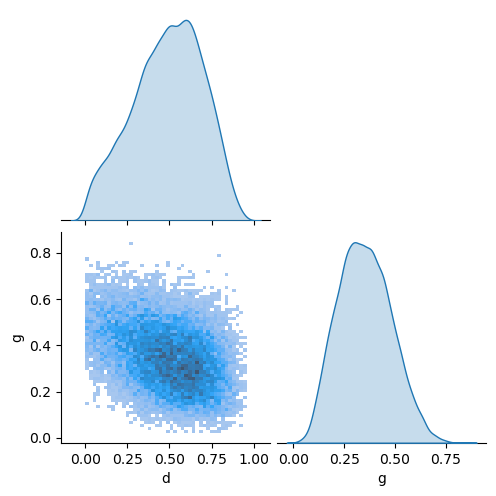

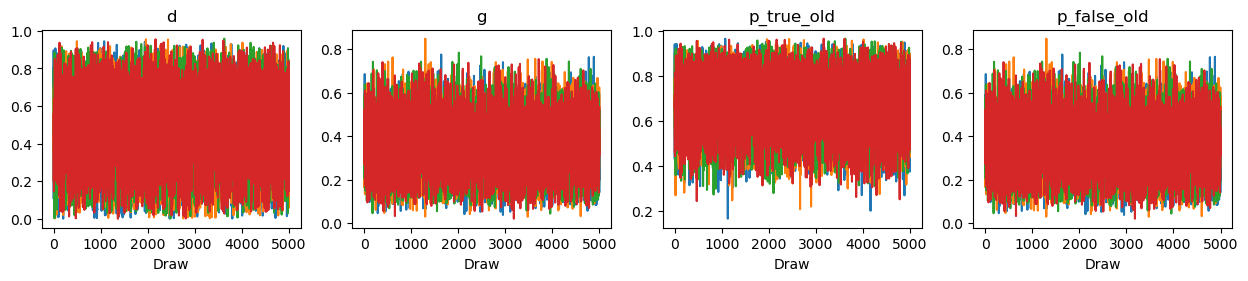

In [ ]:
idata_1ht = az.from_cmdstanpy(
    posterior=fit_1ht,
    posterior_predictive="pred_ans",
    observed_data={"old_ans": data_dict["old_ans"],"new_ans": data_dict["new_ans"]},
)
sns.pairplot(
    fit_1ht.draws_pd(),vars=["d","g"],
    kind="hist",diag_kind="kde",corner=True
)
az.plot_trace(idata_1ht)

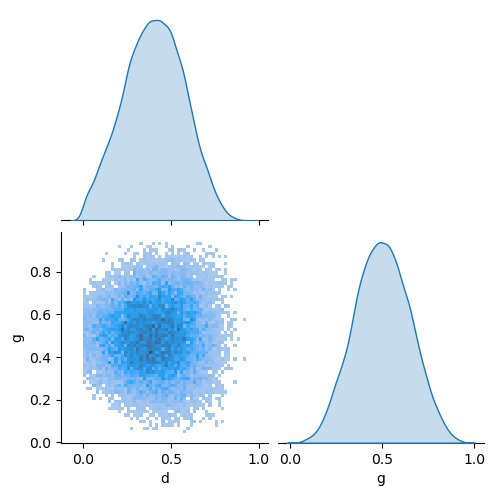

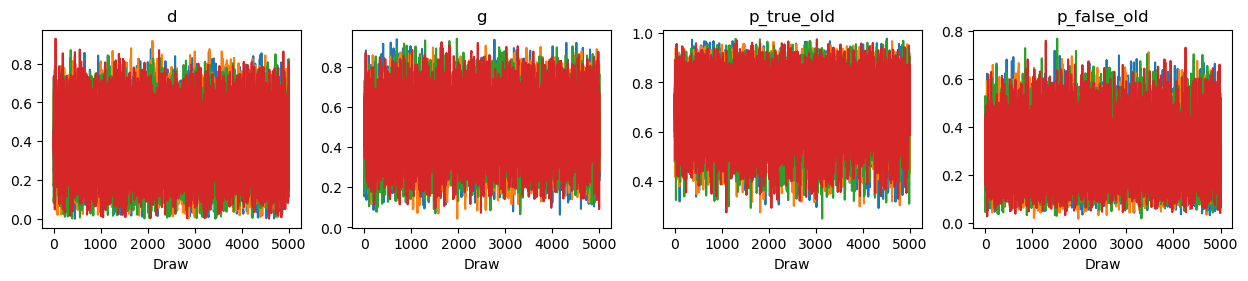

In [48]:
idata_2ht = az.from_cmdstanpy(
    posterior=fit_2ht,
    posterior_predictive="pred_ans",
    observed_data={"old_ans": data_dict["old_ans"],"new_ans": data_dict["new_ans"]},
)
sns.pairplot(
    fit_2ht.draws_pd(),vars=["d","g"],
    kind="hist",diag_kind="kde",corner=True
)
az.plot_trace(idata_2ht)

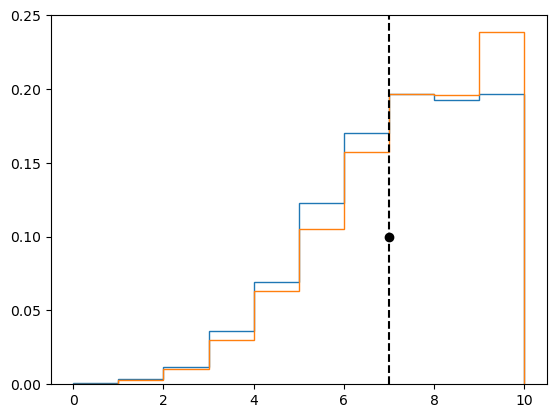

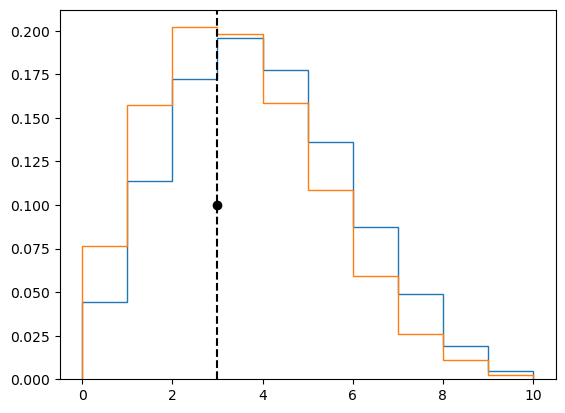

In [73]:
_=plt.hist(idata_1ht.posterior_predictive["pred_ans"].data[:,:,0].flatten(),bins=np.arange(N_old+1),color="C0",histtype="step",density=True)
_=plt.hist(idata_2ht.posterior_predictive["pred_ans"].data[:,:,0].flatten(),bins=np.arange(N_old+1),color="C1",histtype="step",density=True)
plt.scatter(old_answers,0.1,c="k",marker="o")
plt.axvline(old_answers,color="k",ls="--")
plt.figure()
_=plt.hist(idata_1ht.posterior_predictive["pred_ans"].data[:,:,1].flatten(),bins=np.arange(N_new+1),color="C0",histtype="step",density=True)
_=plt.hist(idata_2ht.posterior_predictive["pred_ans"].data[:,:,1].flatten(),bins=np.arange(N_new+1),color="C1",histtype="step",density=True)
plt.scatter(new_answers,0.1,c="k",marker="o")
plt.axvline(new_answers,color="k",ls="--")
